
# Home Task

Apply various clustering algorithms

- Agglomerative clustering using complete linkage
- Agglomerative clustering using single linkage
- DBSCAN
- Use albow method to determine the best k for Kmeans


In [125]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

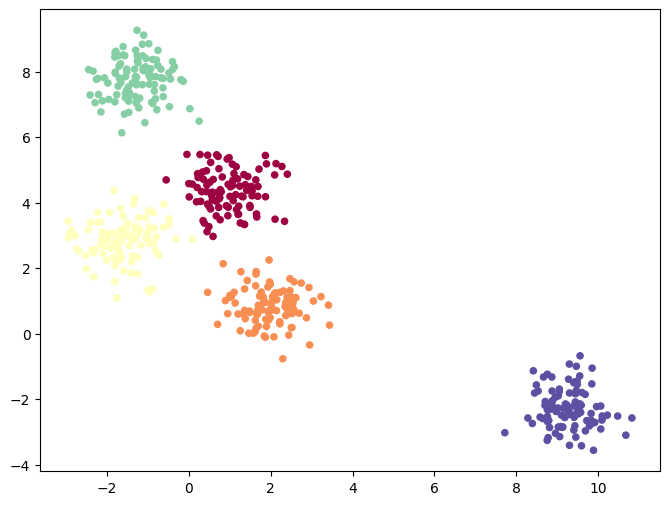

In [126]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, 
                           cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val)
          for val in np.linspace(0, 1, len(set(y)))])
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20)    

# Agglomerative clustering using single linkage

In [127]:
def calc_distances(X):
    all_distances = {}
    for i in range(len(X)):
        for j in range(i+1):
            key_distance = '{},{}'.format(i,j)
            reversed_key_distance = '{},{}'.format(j,i)
            all_distances[key_distance] = all_distances[reversed_key_distance] = np.linalg.norm(X[i] - X[j])
    return all_distances


calc_distances(X)

{'0,0': np.float64(0.0),
 '1,0': np.float64(4.869226842005236),
 '0,1': np.float64(4.869226842005236),
 '1,1': np.float64(0.0),
 '2,0': np.float64(5.258464994236333),
 '0,2': np.float64(5.258464994236333),
 '2,1': np.float64(1.7963026318185227),
 '1,2': np.float64(1.7963026318185227),
 '2,2': np.float64(0.0),
 '3,0': np.float64(5.143513954052262),
 '0,3': np.float64(5.143513954052262),
 '3,1': np.float64(2.140275169924381),
 '1,3': np.float64(2.140275169924381),
 '3,2': np.float64(3.9354890937827323),
 '2,3': np.float64(3.9354890937827323),
 '3,3': np.float64(0.0),
 '4,0': np.float64(4.075628881208287),
 '0,4': np.float64(4.075628881208287),
 '4,1': np.float64(0.8839447670835558),
 '1,4': np.float64(0.8839447670835558),
 '4,2': np.float64(2.324701806112349),
 '2,4': np.float64(2.324701806112349),
 '4,3': np.float64(1.8815015923152518),
 '3,4': np.float64(1.8815015923152518),
 '4,4': np.float64(0.0),
 '5,0': np.float64(7.082023448634877),
 '0,5': np.float64(7.082023448634877),
 '5,1': n

In [128]:
def calc_min_distance(claster_a, claster_b, all_dist):
    distances = []
    for ind_a in claster_a:
        for ind_b in claster_b:
            distances.append(all_dist['{},{}'.format(ind_a, ind_b)])

    return min(distances)

In [129]:
def compute_merge_for_min(clusters, all_dist):
    labels = list(clusters.keys())
    num_labels = len(labels)
    min_distance = calc_min_distance(clusters[labels[0]], clusters[labels[1]], all_dist)
    clus_to_merge = [labels[0], labels[1]]

    for i in range(num_labels-1):
        for j in range(i+1, num_labels):
            curr_min_dist = calc_min_distance(clusters[labels[i]], clusters[labels[j]], all_dist)
            
            if min_distance > curr_min_dist:
                min_distance = curr_min_dist
                clus_to_merge = [labels[i], labels[j]]

    return min_distance, clus_to_merge


In [130]:
def merge_clusters(curr_clusters, clus_to_merge):

    curr_clusters[clus_to_merge[0]] += curr_clusters[clus_to_merge[1]]
    del curr_clusters[clus_to_merge[1]]

    return curr_clusters

In [131]:
def run_clustering_for_min(X, n_clusters=2):
    res_clust = {i: [i] for i in range(len(X))}
    all_dist = calc_distances(X)

    while len(res_clust) > n_clusters:
        _, clus_to_merge = compute_merge_for_min(res_clust, all_dist)
        res_clust = merge_clusters(res_clust, clus_to_merge)

    return res_clust

In [132]:
result = run_clustering_for_min(X, 3)
print("Complete")

Complete


Text(0.5, 1.0, 'manual agglomerative')

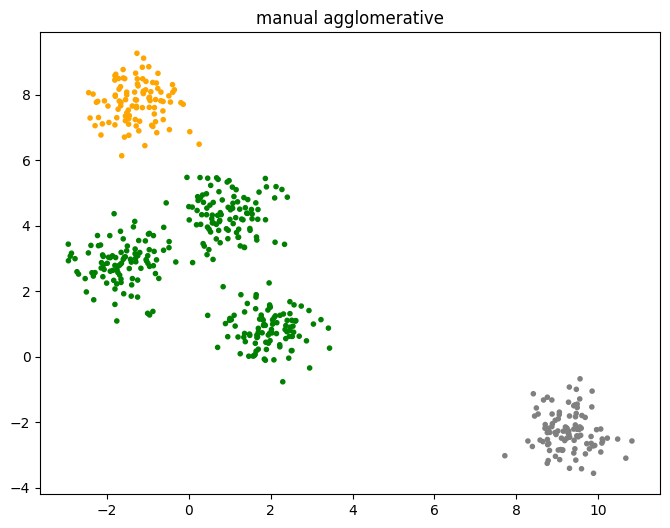

In [133]:
enumerated = {i: value[1] for i, value in enumerate(result.items())}
predicted = [k for i in range(len(X)) for k, v in enumerated.items() if i in v ]


plt.figure(figsize=(8,6))
colors = np.array(['green','grey', 'orange', 'brown', 'blue', 'yellow'])
plt.scatter(X[:,0], X[:,1], c=colors[predicted], marker='.')    
plt.title ('manual agglomerative')


# Agglomerative clustering using complete linkage


To implement Complete Linkage we need to change the distance metric between clusters. Instead of using the minimum distance (Single Linkage) we must use the maximum distance between any two points in the two clusters being compared.

In [134]:
def calc_max_distance(claster_a, claster_b, all_dist):
    distances = []
    for ind_a in claster_a:
        for ind_b in claster_b:
            distances.append(all_dist['{},{}'.format(ind_a, ind_b)])

    return max(distances) 

In [135]:
def compute_merge_for_max(clusters, all_dist):
    labels = list(clusters.keys())
    num_labels = len(labels)
    min_distance = calc_max_distance(clusters[labels[0]], clusters[labels[1]], all_dist)
    clus_to_merge = [labels[0], labels[1]]

    for i in range(num_labels-1):
        for j in range(i+1, num_labels):
            curr_max_dist = calc_max_distance(clusters[labels[i]], clusters[labels[j]], all_dist)
            
            if min_distance > curr_max_dist:
                min_distance = curr_max_dist
                clus_to_merge = [labels[i], labels[j]]

    return min_distance, clus_to_merge

In [136]:
def run_clustering_for_max(X, n_clusters=2):
    res_clust = {i: [i] for i in range(len(X))}
    all_dist = calc_distances(X)

    while len(res_clust) > n_clusters:
        _, clus_to_merge = compute_merge_for_max(res_clust, all_dist)
        res_clust = merge_clusters(res_clust, clus_to_merge)

    return res_clust

In [137]:
result_1 = run_clustering_for_max(X, 3)
print("Complete")

Complete


Text(0.5, 1.0, 'agglomerative')

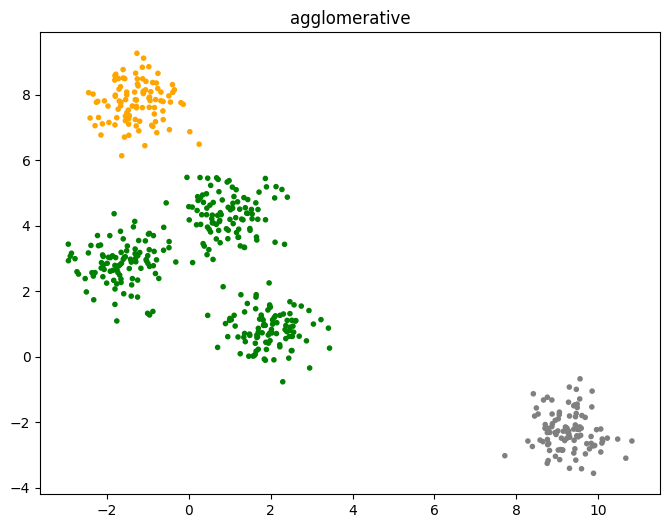

In [138]:
enumerated = {i: value[1] for i, value in enumerate(result_1.items())}
predicted = [k for i in range(len(X)) for k, v in enumerated.items() if i in v ]


plt.figure(figsize=(8,6))
colors = np.array(['green','grey', 'orange', 'brown', 'blue', 'yellow'])
plt.scatter(X[:,0], X[:,1], c=colors[predicted], marker='.')    
plt.title ('agglomerative')


# DBSCAN

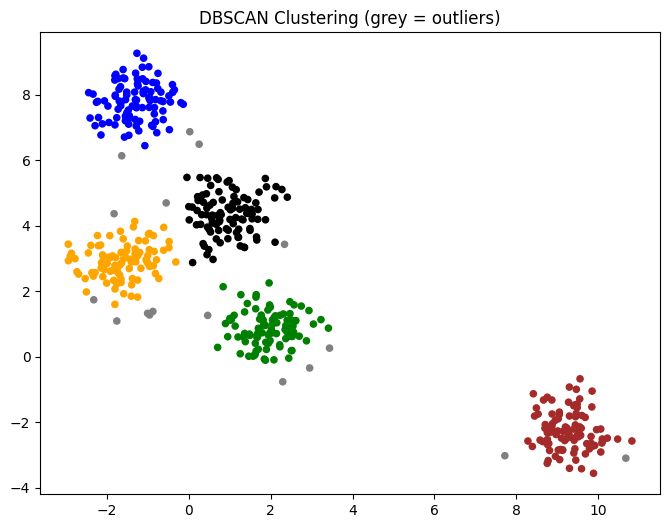

Estimated number of clusters: 5
Estimated number of outliers points: 17


In [139]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X)


plt.figure(figsize=(8,6))

colors = np.array(['green','black', 'orange', 'brown', 'blue', 'yellow'])

col_arr = ['grey' if c == -1 else colors[c] for c in clusters_dbscan]

plt.scatter(X[:,0], X[:,1], c=col_arr, s=20)
plt.title('DBSCAN Clustering (grey = outliers)')
plt.show()

n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_outliers = list(clusters_dbscan).count(-1)
print(f'Estimated number of clusters: {n_clusters}')
print(f'Estimated number of outliers points: {n_outliers}')

# Use elbow method to determine the best k for Kmeans


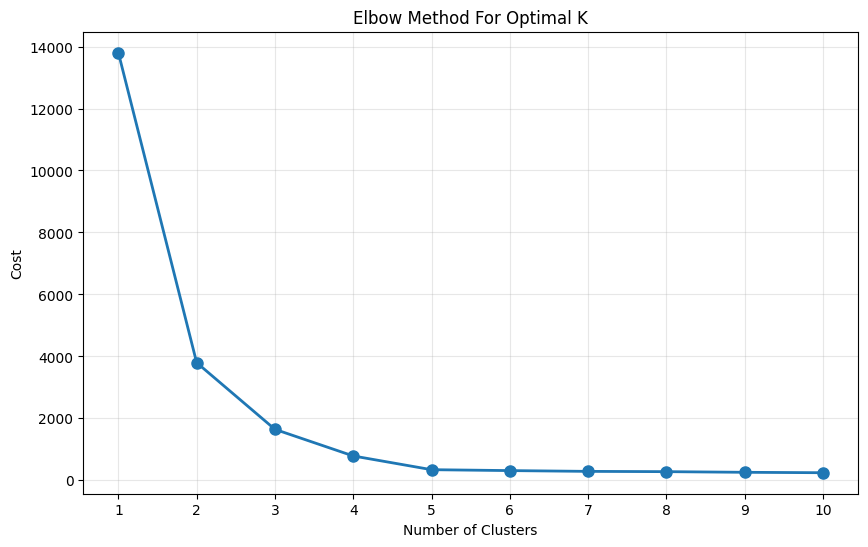

K=1: Cost=13801.1190
K=2: Cost=3798.0664
K=3: Cost=1645.9219
K=4: Cost=787.0677
K=5: Cost=343.8869
K=6: Cost=314.6023
K=7: Cost=289.4107
K=8: Cost=280.4989
K=9: Cost=259.5103
K=10: Cost=245.9471


In [140]:
from sklearn.cluster import KMeans

K_val = range(1, 11)
costs = []

for K in K_val:
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(X)
    costs.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_val, costs, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal K')
plt.grid(True, alpha=0.3)
plt.xticks(K_val)
plt.show()

for K, cost in zip(K_val, costs):
    print(f"K={K}: Cost={cost:.4f}")